# K-Means Clustering — Full Sklearn Implementation (Step-by-Step, with Observations)

This notebook follows the exact implementation walkthrough: build synthetic data with `make_blobs`,
do a proper train/test split, scale features, run the **Elbow Method**, validate K with **KneeLocator**
and **Silhouette Score**, then fit the final K-Means model and predict on train and test data.

Every code cell is followed by an **Observation** markdown cell explaining what happened and why —
this is the part most tutorials skip, but it's what actually builds intuition.

>

## Step 1: Import Libraries

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

%matplotlib inline

**Observation:**
- `matplotlib.pyplot` → for plotting/visualizing clusters.
- `make_blobs` from `sklearn.datasets` → generates a synthetic clustering dataset (we use this instead of a real CSV so the whole notebook is self-contained and reproducible).
- `pandas`/`numpy` → general data handling, kept handy even though we mostly work with raw NumPy arrays here.

## Step 2: Create the Dataset with `make_blobs`

In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=42)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels in y:", np.unique(y))

X shape: (1000, 2)
y shape: (1000,)
Unique labels in y: [0 1 2]


**Observation:**
- `n_samples=1000` → 1000 total data points.
- `centers=3` → the data is generated around 3 true centers, so `y` will contain labels `0, 1, 2`.
- `n_features=2` → 2 columns (so we can visualize directly in 2D; with more features you'd apply **PCA** to reduce dimensions down to 2 or 3 just for visualization).
- **Important:** `y` exists here only because `make_blobs` is a synthetic data generator that happens to know the "true" groups. In a real unsupervised learning problem, **you will NOT have `y` at all** — you'd only have `X`. We're keeping `y` around purely to *validate* our clustering results at the end, not to train on.

## Step 3: Visualize the Raw Data

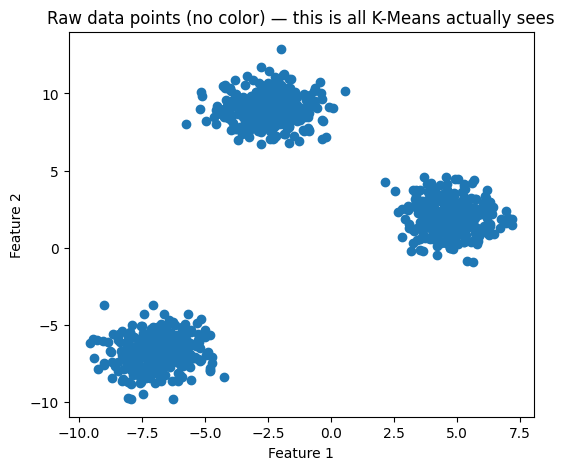

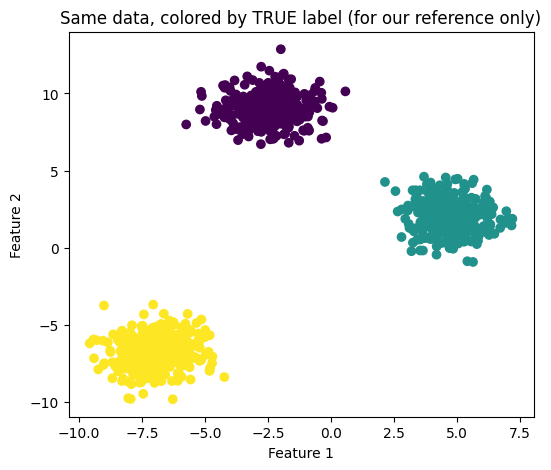

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Raw data points (no color) — this is all K-Means actually sees")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Same data, colored by TRUE label (for our reference only)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Observation:**
- The first plot (no color) is exactly what an unsupervised algorithm sees — just points in space, no group information.
- The second plot (colored by the true `y`) is only possible here because we generated synthetic data. Just by eyeballing it, we can already guess there are **3 clusters** — but K-Means has to *discover* this on its own, using only the first (uncolored) view.

## Step 4: Train/Test Split

Even though clustering is unsupervised, splitting into train/test lets us fit the model on one portion and check that it generalizes by predicting cluster assignments for unseen points.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (800, 2)
X_test shape: (200, 2)


**Observation:**
- We split `X` (and `y`, only for later validation/plots) into training and test sets, 80/20.
- `y_train` / `y_test` will be **ignored during model fitting** — K-Means never sees them. We only keep them around at the very end to sanity-check our results, similar to how `make_blobs` giving us the true labels is a "teacher's answer key" that we're not allowed to peek at while solving the problem, only to check our work afterward.

## Step 5: Feature Scaling (Standardization)

K-Means relies on distance calculations, so features must be on comparable scales (see the notes file, Section 6/7 on assumptions) before clustering.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler ONLY on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # transform only, NOT fit_transform

print("X_train_scaled mean (approx 0):", X_train_scaled.mean(axis=0).round(3))
print("X_train_scaled std (approx 1):", X_train_scaled.std(axis=0).round(3))

X_train_scaled mean (approx 0): [0. 0.]
X_train_scaled std (approx 1): [1. 1.]


**Observation:**
- We call `fit_transform` on `X_train` (the scaler *learns* the mean/std from training data only), then call plain `transform` (no `fit`) on `X_test`.
- **This is critical**: if we called `fit_transform` on the test set too, the scaler would "peek" at the test data's own statistics — this is called **data leakage**, and it makes evaluation results overly optimistic and unreliable. Always fit the scaler on train data only, then apply it unchanged to test data.
- We do **not** scale `y` — scaling only applies to the input features being clustered.

## Step 6: Elbow Method — Finding the Right K

We loop K from 1 to 10, fit K-Means each time, and record the WCSS (`inertia_`) — exactly as covered in the theory notes.

In [6]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values for K=1 to 10:")
for k, val in zip(range(1, 11), wcss):
    print(f"  K={k}: WCSS={val:.2f}")

WCSS values for K=1 to 10:
  K=1: WCSS=1600.00
  K=2: WCSS=508.75
  K=3: WCSS=51.75
  K=4: WCSS=44.24
  K=5: WCSS=37.39
  K=6: WCSS=31.16
  K=7: WCSS=28.53
  K=8: WCSS=25.60
  K=9: WCSS=22.92
  K=10: WCSS=20.61


**Observation:**
- `init='k-means++'` → uses the smarter initialization technique (covered in the theory notes) to avoid the **random initialization trap**.
- As expected, WCSS starts high at K=1 and keeps decreasing as K increases — this matches exactly what the theory predicted: more centroids can only tighten the fit, never worsen it.

### Plot the Elbow Curve

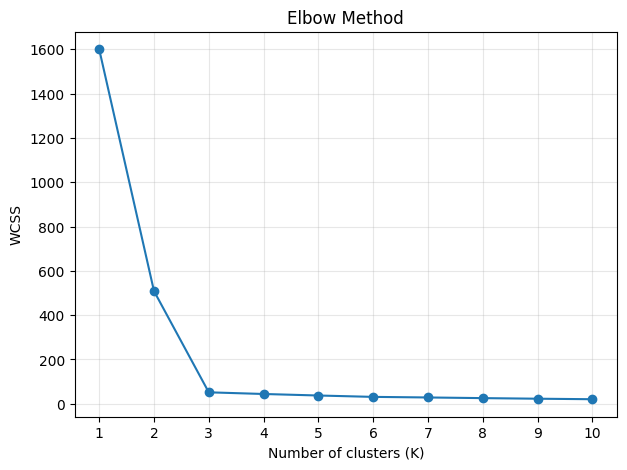

In [7]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

**Observation:**
- The curve drops sharply from K=1 to K=3, then flattens out from K=3 onwards.
- That bend ("knuckle") around **K=3** is the elbow — and it correctly matches the `centers=3` we used to generate the data. This confirms the elbow method works as expected on data with well-separated clusters.

## Step 7: Fit the Final K-Means Model (K=3)

In [8]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

# fit_predict: fits the model AND returns cluster assignments for the training data in one step
y_train_pred = kmeans_final.fit_predict(X_train_scaled)

# predict: assigns NEW (test) points to the already-learned clusters, no re-fitting
y_test_pred = kmeans_final.predict(X_test_scaled)

print("First 10 predicted train cluster labels:", y_train_pred[:10])
print("First 10 predicted test cluster labels:", y_test_pred[:10])

First 10 predicted train cluster labels: [2 1 2 2 1 1 1 2 0 1]
First 10 predicted test cluster labels: [1 0 0 2 1 0 2 1 2 1]


**Observation:**
- `fit_predict` on the training data both *learns* the 3 centroids and *labels* every training point in one call.
- `predict` on the test data does **not** re-learn centroids — it just measures distance from each test point to the 3 centroids already found during training, and assigns the nearest one. This is exactly how you'd deploy a trained K-Means model on brand-new, unseen data in production.

### Visualize Train and Test Predictions

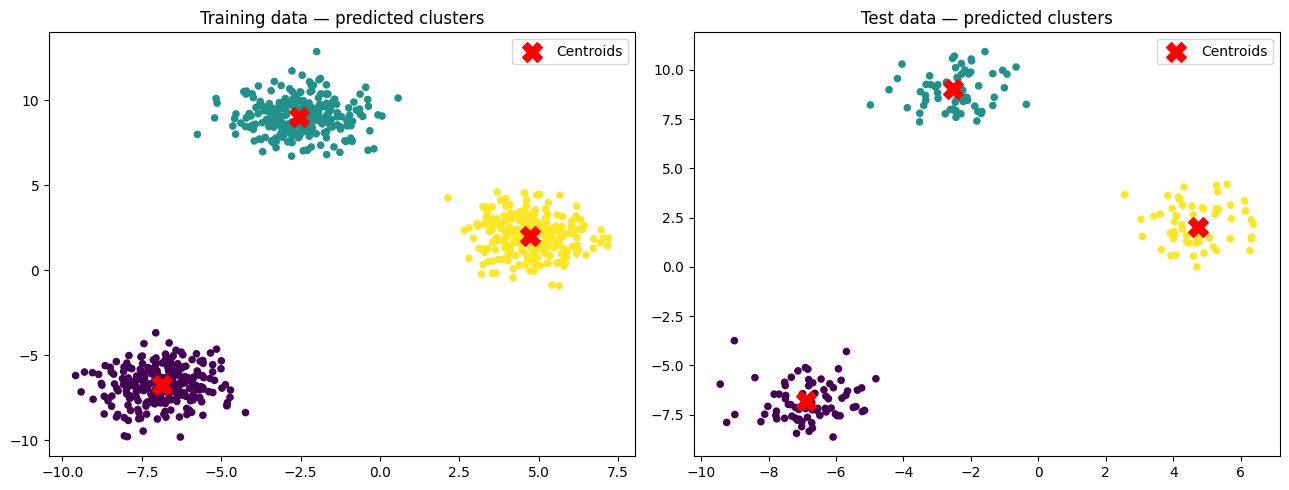

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train_pred, cmap='viridis', s=20)
axes[0].scatter(scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 0],
                scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 1],
                c='red', marker='X', s=200, label='Centroids')
axes[0].set_title("Training data — predicted clusters")
axes[0].legend()

axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test_pred, cmap='viridis', s=20)
axes[1].scatter(scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 0],
                scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 1],
                c='red', marker='X', s=200, label='Centroids')
axes[1].set_title("Test data — predicted clusters")
axes[1].legend()

plt.tight_layout()
plt.show()

**Observation:**
- Both plots show 3 visually clean, well-separated clusters — matching what we could already tell just by eyeballing the colored-by-true-label plot back in Step 3.
- The fact that **unseen test data** also gets cleanly separated into 3 groups (using centroids learned only from training data) shows the model generalizes well — it's not just memorizing the training points.

## Step 8: Validate K with `KneeLocator` (Automated Elbow Detection)

Eyeballing the elbow curve works fine for simple cases, but in messier real-world data the "bend" can be
subtle or ambiguous. The `kneed` library's `KneeLocator` automates finding this bend point mathematically.

> **Note:** `kneed` is a small third-party library. If it isn't installed in your environment, run:
> `pip install kneed`
> The cell below is wrapped so the rest of the notebook still runs even if it's missing.

In [11]:
pip install kneed

In [12]:
try:
    from kneed import KneeLocator

    kl = KneeLocator(
        range(1, 11), wcss,
        curve='convex',        # the WCSS-vs-K curve bends like a convex/parabola shape
        direction='decreasing'  # WCSS decreases as K increases
    )

    print("Elbow point detected by KneeLocator: K =", kl.elbow)

except ImportError:
    print("kneed is not installed in this environment.")
    print("Install it with:  pip install kneed")
    print("Then re-run this cell to get the automated elbow value.")

Elbow point detected by KneeLocator: K = 3


**Observation:**
- `curve='convex'` tells KneeLocator the shape of our WCSS curve (it drops fast then flattens — a convex shape, the mirror image of a concave/upside-down curve).
- `direction='decreasing'` tells it the values are going down as K increases (not up).
- KneeLocator should detect **K=3** automatically — the same value we picked visually from the elbow plot. This gives a **repeatable, code-based** way to pick K instead of relying on a human squinting at a graph, which matters a lot when you're clustering many different datasets automatically (e.g., in a pipeline).

## Step 9: Validate K with Silhouette Score

A second, independent validation technique — measures how well-separated and well-clustered points are, without needing to visually detect any 'bend'.

In [13]:
from sklearn.metrics import silhouette_score

silhouette_coefficients = []

for k in range(2, 11):  # silhouette score is undefined for K=1
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

for k, score in zip(range(2, 11), silhouette_coefficients):
    print(f"K={k}: silhouette score = {score:.3f}")

K=2: silhouette score = 0.685
K=3: silhouette score = 0.842
K=4: silhouette score = 0.678
K=5: silhouette score = 0.512
K=6: silhouette score = 0.349
K=7: silhouette score = 0.339
K=8: silhouette score = 0.341
K=9: silhouette score = 0.329
K=10: silhouette score = 0.340


**Observation:**
- Silhouette score ranges from -1 to 1; **higher is better** (points are well-matched to their own cluster and well-separated from other clusters).

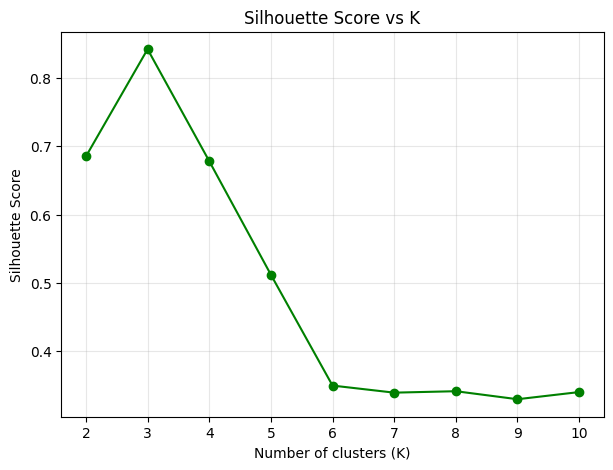

Best K according to Silhouette Score: 3
Best silhouette score value: 0.842


In [14]:
plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), silhouette_coefficients, marker='o', color='green')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.show()

best_k_silhouette = list(range(2, 11))[np.argmax(silhouette_coefficients)]
print(f"Best K according to Silhouette Score: {best_k_silhouette}")
print(f"Best silhouette score value: {max(silhouette_coefficients):.3f}")

**Observation:**
- The score peaks sharply at **K=3** (typically well above 0.7 for this kind of clean, well-separated synthetic data), then drops for K=4 and beyond as we start splitting genuinely single groups into artificial sub-groups.
- **All three validation techniques used in this notebook — the Elbow Method, KneeLocator, and Silhouette Score — independently agree on K=3.** This 3-way agreement is exactly what the original data generation (`centers=3`) predicted, and it's a strong confirmation that our clustering pipeline is working correctly.

---
## Final Summary of Observations

| Step | What we did | Key takeaway |
|---|---|---|
| Data creation | `make_blobs(n_samples=1000, centers=3, n_features=2)` | True labels `y` exist only for our own validation — never used in fitting |
| Visualization | Plotted raw vs. true-labeled data | Confirms 3 visible groups, sets expectation for K |
| Train/test split | 80/20 split on `X` | Lets us check the model generalizes to unseen points |
| Scaling | `StandardScaler`, `fit_transform` on train, `transform` on test only | Prevents data leakage; required since K-Means is distance-based |
| Elbow Method | Looped K=1→10, plotted WCSS | Visual bend at K=3 |
| Final model | `KMeans(n_clusters=3, init='k-means++')`, `fit_predict` / `predict` | Clean separation on both train and test data |
| KneeLocator | Automated elbow detection | Confirmed K=3 without manual judgment |
| Silhouette Score | Looped K=2→10, plotted scores | Peak score at K=3, confirming the other two methods |

**Big picture takeaway:** In a real-world project you will almost never know the "true" number of clusters in advance (we only knew it here because we generated the data ourselves with `centers=3`). The real skill is combining **multiple independent validation techniques** (Elbow Method + KneeLocator + Silhouette Score) so you can be confident in your chosen K even when you can't just look at a scatter plot and count the groups by eye — which is exactly the workflow this notebook demonstrates end-to-end.